In [11]:
import os
import pandas as pd
from importlib import reload
import numpy as np
import seaborn as sns
from tqdm import *
import scipy.special
from numpy.linalg import eigh
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
plt.style.use('default')  # 防止暗色主题影响图片背景

In [12]:
def concat_model_4fold(test_path, res_path):
    market = 'ALL'
    model_res = []
    for fold in range(1, 5):
        # 匹配当前命名规则：目录以 --fold{fold} 结尾
        fold_dirs = [d for d in os.listdir(test_path) if d.endswith(f'--fold{fold}')]
        if len(fold_dirs) == 0:
            print(f"Warning: No directory found for fold{fold} in {test_path}")
            continue
        data_path = rf"{test_path}/{fold_dirs[0]}"
        date_list = list(set([x[:8] for x in os.listdir(data_path)]))
        date_list.sort()
        all_res = []
        for date in date_list:
            date_res = pd.read_pickle(f'{data_path}/{date}.pkl').T
            date_res.index = [date] * len(date_res)
            all_res.append(date_res)
        all_res = pd.concat(all_res, axis=0).sort_index()
        all_res.index.name = "date"
        model_res.append(all_res.apply(lambda x: (x - x.mean()) / x.std(), axis=1))
    model_res = sum(model_res)
    os.makedirs(res_path, exist_ok=True)
    model_res.reset_index().to_feather(rf"{res_path}/{market}_zscore_score.fea")
    return model_res

# 根据模型打分获取对应的label_ret和ic
def get_ret_ic(score, ret_data, liquid_data, start='20230101', end='20241231', money=1.5e9, print_quarterly=False):
    model_score = score.copy()
    label_ret = []
    ic = []
    datelist = []
    # 这是一段日度调仓计算日度收益率的代码
    for date in model_score.loc[start:end].index:
        datelist.append(date)
        code_rank = model_score.loc[date].sort_values(ascending=False)
        ret = ret_data.loc[date].reindex(code_rank.index).fillna(0) * 100
        liquid = liquid_data.loc[date].reindex(code_rank.index).fillna(0)
        total_hold = 0
        total_earned = 0
        for num,code in enumerate(code_rank.index):
            if num >= 500:
                break
            if (money - total_hold) < 1:
                break
            hold_money = min(money - total_hold, liquid[code])
            total_hold += hold_money
            total_earned += ret[code] * hold_money
        total_ret = total_earned / money
        label_ret.append(total_ret)
        ic.append(code_rank.corr(ret))
    ic = pd.Series(ic, index=datelist, dtype='float')
    label_ret = pd.Series(label_ret, index=datelist, dtype='float')
    if print_quarterly:
        print_quarterly_metrics(label_ret, ic)
    return label_ret, ic

def print_quarterly_metrics(ret, ic):
    """打印每个季度的收益和IC指标"""
    ret_series = ret.copy()
    ic_series = ic.copy()
    ret_series.index = pd.to_datetime(ret_series.index)
    ic_series.index = pd.to_datetime(ic_series.index)
    quarterly_ret = ret_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ic = ic_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ret.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ret.index]
    quarterly_ic.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ic.index]
    quarterly_df = pd.DataFrame({
        '季度平均收益': quarterly_ret.round(4),
        '季度平均IC': quarterly_ic.round(4)
    })
    print("\n===== 季度表现指标 =====")
    print(quarterly_df)
    print("=======================\n")

def get_metrics(score, ret_data, liquid_data, start='20230101', end='20241231', money=1.5e9, print_quarterly=True):
    ret_list, ic_list = get_ret_ic(score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=print_quarterly)
    # 当前模型评价
    score_metrics = {
        "IC": ic_list.mean(),
        "ICIR": ic_list.mean() / ic_list.std() if ic_list.std() != 0 else 0,
        "top_return": ret_list.mean(),
        "top_return_stability": ret_list.mean() / ret_list.std() if ret_list.std() != 0 else 0
    }
    return score_metrics

def print_metrics(model_metrics, bench_metrics=None, title="模型评估结果"):
    metric_keys = list(model_metrics.keys())
    df = pd.DataFrame(index=metric_keys)
    df.index.name = "指标"
    df["模型值"] = [model_metrics[k] for k in metric_keys]
    if bench_metrics is not None:
        df["基准值"] = [bench_metrics.get(k, None) for k in metric_keys]
        df["提升值"] = ((df["模型值"] - df["基准值"]) / df["基准值"]) * 100
    print(f"\n{title}")
    print(df.round(4))

def plot_model(model_score, bench_score, ret_data, liquid_data, start='20230101', end='20241231', money=1.5e9):
    model_ret, _ = get_ret_ic(model_score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=False)
    model_ret = model_ret/100
    bench_ret, _ = get_ret_ic(bench_score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=False)
    bench_ret = bench_ret/100

    dates = model_ret.index.tolist()
    seen_months = set()
    month_ticks = []
    month_labels = []
    for i, d in enumerate(dates):
        month = d[:6] 
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)

    # 1. 绘制每日收益率曲线
    plt.figure(figsize=(12, 6))
    plt.plot(dates, model_ret.cumsum(), label='model', color='blue')
    plt.plot(dates, bench_ret.cumsum(), label='bench', color='orange')
    plt.title('Cumulative Return Of Model & Bench', fontsize=14)
    plt.ylabel('Cumulative Return(%)', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 2. 绘制相对提升
    plt.figure(figsize=(12, 6))
    relative_improvement = model_ret - bench_ret
    plt.plot(dates, relative_improvement.cumsum(), label='model', color='blue')
    plt.title('Relative Iprovement', fontsize=14)
    plt.ylabel('Relative Iprovement(%)', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

def diversity_entropy(score):
    """
    计算 DE
    """
    if isinstance(score, pd.DataFrame):
        score = score.values
    m = score.shape[1]
    cov_matrix = np.cov(score, rowvar=False)
    eigenvalues, _ = eigh(cov_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    normalized_eigenvalues = eigenvalues / (np.sum(eigenvalues) + 1e-10)
    entropy = 0
    for p in normalized_eigenvalues:
        if p > 1e-10:  # 只对非零概率计算
            entropy -= p * np.log(p)
    de = entropy / np.log(m)
    return de

def ensemble_scores(*dfs):
    """
    输入：任意数量的打分 DataFrame（index=日期，columns=股票）
    输出：拼接后的 DataFrame，columns=score1, score2, ...
    """
    result_list = []
    for i, df in enumerate(dfs, 1):
        df_norm = df.copy()
        df_norm = df_norm.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
        df_norm = df_norm.stack().rename(f"score{i}")
        result_list.append(df_norm)
    result = pd.concat(result_list, axis=1)
    return result.dropna()

# bench

In [13]:
# 标签
label_path = rf'E:/BaiduSyncdisk/lingqingData/trainingdata/V0'
label_name = rf'label'
# 流动性数据
liquid_path = rf'E:/BaiduSyncdisk/lingqingData/trainingdata/V0'
liquid_name = rf'trade_amt'

class params:
    liquid_data = pd.read_feather(rf"{liquid_path}/{liquid_name}.fea").set_index("index")
    ret_data = pd.read_feather(rf"{label_path}/{label_name}.fea").set_index("index")

# 模型路径与结果路径
root_path = rf'E:/BaiduSyncdisk/Model/V0'
model_test_path = rf'{root_path}/model_test/nn--fac20260510--label--dropout0.2'
model_res_path = rf'{root_path}/model_res'

# 收集模型训练结果
model_score = concat_model_4fold(test_path=model_test_path, res_path=model_res_path)

# 暂时没有bench，四个bench都用自己代替
bench1 = model_score.copy()
bench2 = model_score.copy()
bench3 = model_score.copy()
bench4 = model_score.copy()

bench_all = ensemble_scores(bench1, bench2, bench3, bench4)
de_series = bench_all.groupby('date').apply(diversity_entropy)
print(f'现有子模型的多样性熵：{de_series.mean()}')
print('各子模型之间的相关性：')
print(bench_all.groupby('date').corr().unstack().mean().unstack())

bench_all = bench_all.mean(axis=1).unstack()
bench_all_metrics = get_metrics(bench_all, params.ret_data, params.liquid_data, start='20230101', end='20241231', money=1.5e9, print_quarterly=True)
print_metrics(bench_all_metrics)

现有子模型的多样性熵：1.803370029468569e-11
各子模型之间的相关性：
        score1  score2  score3  score4
score1     1.0     1.0     1.0     1.0
score2     1.0     1.0     1.0     1.0
score3     1.0     1.0     1.0     1.0
score4     1.0     1.0     1.0     1.0

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2024Q1  2.6491  0.1414
2024Q2  1.6579  0.1184
2024Q3  3.1762  0.1390
2024Q4  5.0903  0.2031


模型评估结果
                         模型值
指标                          
IC                    0.1507
ICIR                  1.8215
top_return            3.1622
top_return_stability  0.9523


# 使用示例

---单一模型评估---

===== 季度表现指标 =====
        季度平均收益(%)  季度平均IC
2024Q1     2.6491  0.1414
2024Q2     1.6579  0.1184
2024Q3     3.1762  0.1390
2024Q4     5.0903  0.2031


模型评估结果
                         模型值
指标                          
IC                    0.1507
ICIR                  1.8215
top_return            3.1622
top_return_stability  0.9523
---该模型与现有集成模型的相关性---
1.0000
---模型集成评估---
加入当前模型后的多样性熵：1.2426680027577415e-11
当前模型与现有子模型之间的相关性：
        score1  score2  score3  score4  score5
score1     1.0     1.0     1.0     1.0     1.0
score2     1.0     1.0     1.0     1.0     1.0
score3     1.0     1.0     1.0     1.0     1.0
score4     1.0     1.0     1.0     1.0     1.0
score5     1.0     1.0     1.0     1.0     1.0

===== 季度表现指标 =====
        季度平均收益(%)  季度平均IC
2024Q1     2.6491  0.1414
2024Q2     1.6579  0.1184
2024Q3     3.1762  0.1390
2024Q4     5.0903  0.2031


模型评估结果
                         模型值     基准值  提升值
指标                                       
IC                    0.1507  0.15

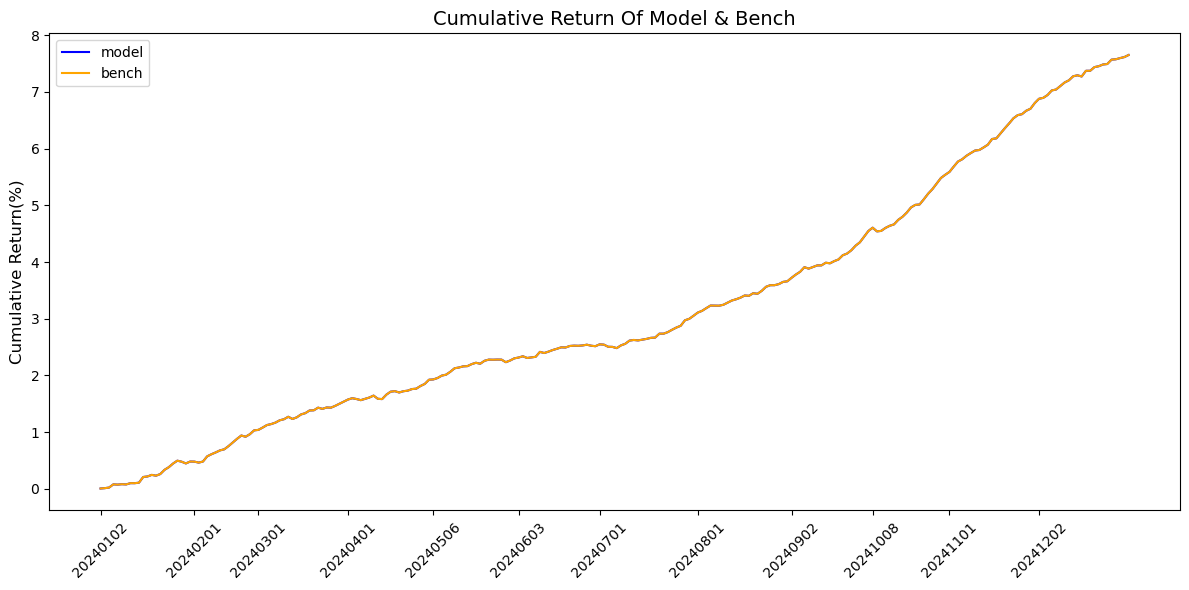

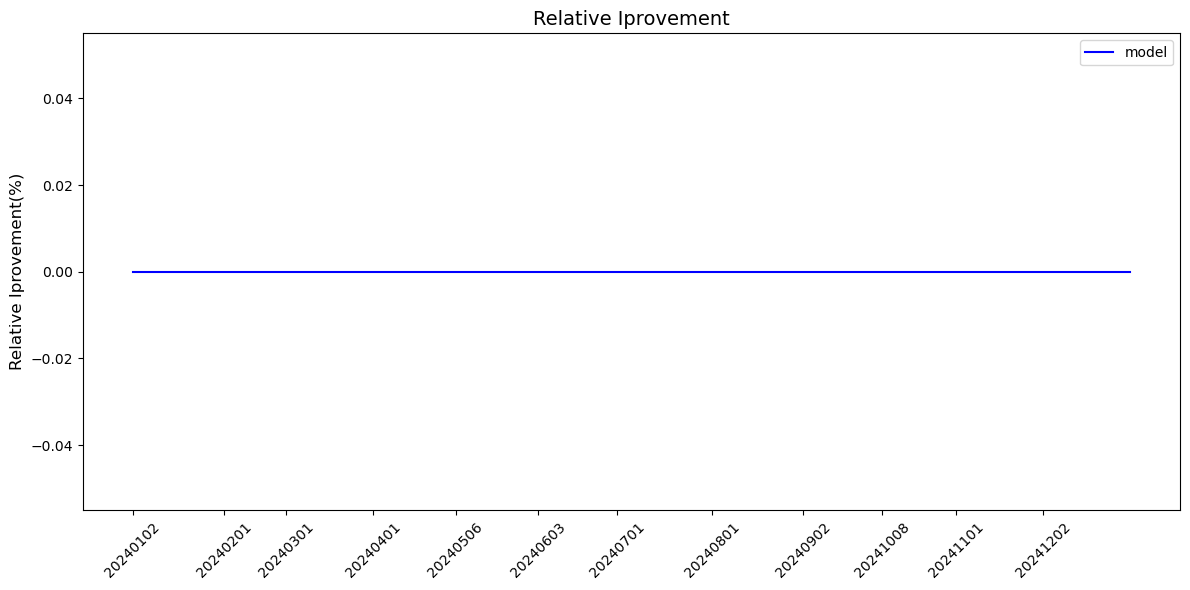

In [10]:
# 单模型效果评估（完整季度输出）
# 注意：当前 bench = 模型自身，集成评估无实际意义，待有真实 bench 后替换 bench1~4 即可
print("---单一模型评估---")
score1_metrics = get_metrics(model_score, params.ret_data, params.liquid_data, start='20230101', end='20241231', money=1.5e9, print_quarterly=True)
print_metrics(score1_metrics)

# TODO: 有真实bench后，取消下面注释并替换 bench1~4
print("---该模型与现有集成模型的相关性---")
corr_with_bench = model_score.reindex(columns=bench_all.columns, index=bench_all.index).corrwith(bench_all, axis=1)
print(f"{corr_with_bench.mean():.4f}")

print("---模型集成评估---")
bench_new = ensemble_scores(bench1, bench2, bench3, bench4, model_score)
print(f'加入当前模型后的多样性熵：{bench_new.groupby("date").apply(diversity_entropy).mean()}')
print('当前模型与现有子模型之间的相关性：')
print(bench_new.groupby('date').corr().unstack().mean().unstack())
bench_new_metrics = get_metrics(bench_new.mean(axis=1).unstack(), params.ret_data, params.liquid_data, start='20230101', end='20241231', money=1.5e9, print_quarterly=True)
print_metrics(bench_new_metrics, bench_all_metrics)
plot_model(bench_new.mean(axis=1).unstack(), bench_all, params.ret_data, params.liquid_data, start='20230101', end='20241231', money=1.5e9)